# Data Preprocessing & Impact Analysis

Analyse approfondie de l'impact du prétraitement sur la qualité des données et la performance des modèles pour la classification NLI.

## Objectifs

- Charger et explorer les données brutes du dataset MultiNLI
- Analyser les caractéristiques textuelles (longueurs, ponctuation, vocabulaire)
- Implémenter différentes stratégies de prétraitement
- Évaluer l'impact de chaque prétraitement sur l'accuracy
- Identifier le meilleur prétraitement pour le pipeline de feature engineering


## 1. Load and Explore Raw Data

Chargement du fichier JSONL, filtrage des labels invalides, et exploration basique de la structure des données.


In [18]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
import time
from collections import Counter

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import MaxAbsScaler
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

# Configuration
DATA_PATH = "../data/raw/multinli_1.0/multinli_1.0_train.jsonl"
MAX_SAMPLES = 80000  # Limiter pour analyse rapide du prétraitement
RANDOM_STATE = 42

print("Configuration initialized")
print(f"Data path: {DATA_PATH}")
print(f"Max samples for analysis: {MAX_SAMPLES}")

Configuration initialized
Data path: ../data/raw/multinli_1.0/multinli_1.0_train.jsonl
Max samples for analysis: 80000


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hagop\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 2. Analyze Text Characteristics

Analyse des distributions de longueur, ponctuation, et vocabulaire pour guider le prétraitement.


In [19]:
data = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        if item["gold_label"] == "-":
            continue
        data.append(item)
        if len(data) >= MAX_SAMPLES:
            break

df = pd.DataFrame(data)[["sentence1", "sentence2", "gold_label"]]

print(f"Total samples loaded: {len(df)}")
print(f"\nLabel distribution:")
print(df["gold_label"].value_counts())
print(f"\nLabel proportions:")
print(df["gold_label"].value_counts(normalize=True).round(4))

print("\n=== First 3 Examples ===")
for i in range(min(3, len(df))):
    print(f"\nExample {i+1}:")
    print(f"  Sentence1: {df.iloc[i]['sentence1'][:80]}...")
    print(f"  Sentence2: {df.iloc[i]['sentence2'][:80]}...")
    print(f"  Label: {df.iloc[i]['gold_label']}")

Total samples loaded: 80000

Label distribution:
gold_label
contradiction    28394
entailment       27122
neutral          24484
Name: count, dtype: int64

Label proportions:
gold_label
contradiction    0.3549
entailment       0.3390
neutral          0.3060
Name: proportion, dtype: float64

=== First 3 Examples ===

Example 1:
  Sentence1: Conceptually cream skimming has two basic dimensions - product and geography....
  Sentence2: Product and geography are what make cream skimming work. ...
  Label: neutral

Example 2:
  Sentence1: you know during the season and i guess at at your level uh you lose them to the ...
  Sentence2: You lose the things to the following level if the people recall....
  Label: entailment

Example 3:
  Sentence1: One of our number will carry out your instructions minutely....
  Sentence2: A member of my team will execute your orders with immense precision....
  Label: entailment


## 3. Define Preprocessing Functions

Implémenter différentes stratégies de prétraitement modulaires et composables.


=== Text Statistics ===

Sentence 1:
  mean_length: 19.73
  std_length: 14.18
  min_length: 1
  max_length: 272
  median_length: 17.00
  mean_punct: 2.77
  unique_words: 96708
  total_words: 1578361

Sentence 2:
  mean_length: 9.92
  std_length: 4.24
  min_length: 1
  max_length: 60
  median_length: 9.00
  mean_punct: 1.41
  unique_words: 59937
  total_words: 793840


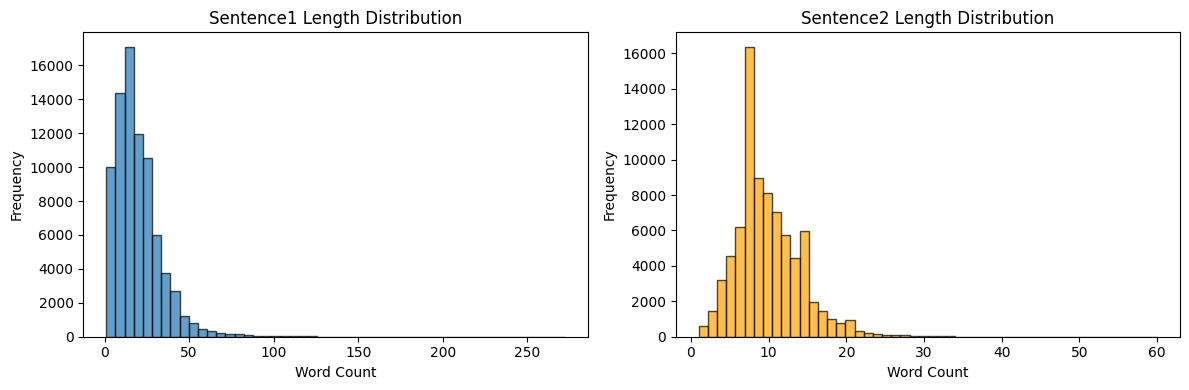


Mean punctuation marks per sentence:
  Sentence1: 2.77
  Sentence2: 1.41


In [20]:
def compute_text_stats(texts):
    """Calculer les statistiques textuelles."""
    lengths = [len(t.split()) for t in texts]
    punct_counts = [sum(1 for c in t if c in string.punctuation) for t in texts]
    all_words = " ".join(texts).split()
    unique_words = len(set(all_words))
    
    return {
        "mean_length": np.mean(lengths),
        "std_length": np.std(lengths),
        "min_length": np.min(lengths),
        "max_length": np.max(lengths),
        "median_length": np.median(lengths),
        "mean_punct": np.mean(punct_counts),
        "unique_words": unique_words,
        "total_words": len(all_words)
    }

# Calculate statistics for both sentences
stats_s1 = compute_text_stats(df['sentence1'].values)
stats_s2 = compute_text_stats(df['sentence2'].values)

print("=== Text Statistics ===\n")
print("Sentence 1:")
for k, v in stats_s1.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.2f}")
    else:
        print(f"  {k}: {v}")

print("\nSentence 2:")
for k, v in stats_s2.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.2f}")
    else:
        print(f"  {k}: {v}")

# Visualize length distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist([len(t.split()) for t in df['sentence1']], bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title('Sentence1 Length Distribution')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

axes[1].hist([len(t.split()) for t in df['sentence2']], bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[1].set_title('Sentence2 Length Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Punctuation analysis
print(f"\nMean punctuation marks per sentence:")
print(f"  Sentence1: {stats_s1['mean_punct']:.2f}")
print(f"  Sentence2: {stats_s2['mean_punct']:.2f}")

## 4. Apply Different Preprocessing Strategies

Appliquer chaque stratégie au dataset complet et stocker les variations.


In [21]:
# Initialize preprocessing tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def lowercase_only(text):
    """Conversion en minuscules."""
    return text.lower()

def remove_punctuation(text):
    """Supprimer la ponctuation."""
    return text.translate(str.maketrans('', '', string.punctuation))

def remove_stopwords(text):
    """Supprimer les stopwords."""
    tokens = text.split()
    return ' '.join([t for t in tokens if t.lower() not in stop_words])

def lemmatize_text(text):
    """Lemmatisation basique."""
    tokens = text.split()
    return ' '.join([lemmatizer.lemmatize(t) for t in tokens])

def preprocessing_no_clean(text):
    """Pas de prétraitement."""
    return text

def preprocessing_lowercase(text):
    """Lowercase seulement."""
    return lowercase_only(text)

def preprocessing_lowercase_punctuation(text):
    """Lowercase + suppression ponctuation."""
    text = lowercase_only(text)
    text = remove_punctuation(text)
    return text

def preprocessing_lowercase_stopwords(text):
    """Lowercase + suppression stopwords."""
    text = lowercase_only(text)
    text = remove_stopwords(text)
    return text

def preprocessing_lowercase_lemmatize(text):
    """Lowercase + lemmatisation."""
    text = lowercase_only(text)
    text = lemmatize_text(text)
    return text

def preprocessing_full(text):
    """Prétraitement complet: lowercase + ponctuation + stopwords + lemmatisation."""
    text = lowercase_only(text)
    text = remove_punctuation(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text

# Dictionary of preprocessing strategies
preprocessing_strategies = {
    "none": preprocessing_no_clean,
    "lowercase": preprocessing_lowercase,
    "lowercase_punct": preprocessing_lowercase_punctuation,
    "lowercase_stopwords": preprocessing_lowercase_stopwords,
    "lowercase_lemma": preprocessing_lowercase_lemmatize,
    "full": preprocessing_full
}

print("Preprocessing functions defined:")
for name in preprocessing_strategies.keys():
    print(f"  - {name}")

# Test on a sample
sample_text = df.iloc[0]['sentence1']
print(f"\n=== Preprocessing Example ===")
print(f"Original: {sample_text[:100]}")
for name, func in preprocessing_strategies.items():
    processed = func(sample_text)
    print(f"{name:20s}: {processed[:100]}")

Preprocessing functions defined:
  - none
  - lowercase
  - lowercase_punct
  - lowercase_stopwords
  - lowercase_lemma
  - full

=== Preprocessing Example ===
Original: Conceptually cream skimming has two basic dimensions - product and geography.
none                : Conceptually cream skimming has two basic dimensions - product and geography.
lowercase           : conceptually cream skimming has two basic dimensions - product and geography.
lowercase_punct     : conceptually cream skimming has two basic dimensions  product and geography
lowercase_stopwords : conceptually cream skimming two basic dimensions - product geography.
lowercase_lemma     : conceptually cream skimming ha two basic dimension - product and geography.
full                : conceptually cream skimming two basic dimension product geography


## 5. Train Baseline Models with Each Preprocessing

Pour chaque variante de prétraitement, entrainer deux modèles baseline (RandomForest, LinearSVC) et mesurer la performance.


In [22]:
print("Applying preprocessing strategies to dataset...")
print("This may take several minutes...\n")

# Dictionary to store processed datasets
preprocessed_data = {}

for strategy_name, preprocess_func in preprocessing_strategies.items():
    print(f"Processing strategy: {strategy_name}...", end=" ")
    start_time = time.time()
    
    # Apply preprocessing
    s1_processed = df['sentence1'].apply(preprocess_func)
    s2_processed = df['sentence2'].apply(preprocess_func)
    
    # Create preprocessed dataframe
    preprocessed_data[strategy_name] = {
        "sentence1": s1_processed,
        "sentence2": s2_processed,
        "label": df['gold_label'],
        "label_encoded": df['gold_label'].map({"entailment": 0, "neutral": 1, "contradiction": 2})
    }
    
    elapsed = time.time() - start_time
    print(f"✓ ({elapsed:.2f}s)")
    
    # Show samples
    print(f"  Sample S1: {s1_processed.iloc[0][:70]}")
    print(f"  Sample S2: {s2_processed.iloc[0][:70]}\n")

print("\nAll preprocessing strategies applied successfully!")
print(f"Total strategies: {len(preprocessed_data)}")

Applying preprocessing strategies to dataset...
This may take several minutes...

Processing strategy: none... ✓ (0.10s)
  Sample S1: Conceptually cream skimming has two basic dimensions - product and geo
  Sample S2: Product and geography are what make cream skimming work. 

Processing strategy: lowercase... ✓ (0.14s)
  Sample S1: conceptually cream skimming has two basic dimensions - product and geo
  Sample S2: product and geography are what make cream skimming work. 

Processing strategy: lowercase_punct... ✓ (0.85s)
  Sample S1: conceptually cream skimming has two basic dimensions  product and geog
  Sample S2: product and geography are what make cream skimming work 

Processing strategy: lowercase_stopwords... ✓ (0.71s)
  Sample S1: conceptually cream skimming two basic dimensions - product geography.
  Sample S2: product geography make cream skimming work.

Processing strategy: lowercase_lemma... ✓ (9.57s)
  Sample S1: conceptually cream skimming ha two basic dimension - product

## 6. Compare Preprocessing Impact on Accuracy

Analyser les deltas de performance et identifier le meilleur prétraitement.


In [23]:
def train_and_evaluate(strategy_name, s1_texts, s2_texts, labels):
    """Entrainer et évaluer les modèles baseline."""
    # Create combined text representation
    combined_texts = (s1_texts + " " + s2_texts).values
    
    # TF-IDF vectorization
    vectorizer = TfidfVectorizer(
        max_features=5000,
        max_df=0.9,
        min_df=2,
        ngram_range=(1, 2),
        sublinear_tf=True
    )
    X = vectorizer.fit_transform(combined_texts)
    labels_encoded = labels.map({"entailment": 0, "neutral": 1, "contradiction": 2}).values
    
    # Train/Test split
    indices = np.arange(len(labels_encoded))
    train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=RANDOM_STATE, stratify=labels_encoded)
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = labels_encoded[train_idx], labels_encoded[test_idx]
    
    results = {}
    
    # RandomForest
    start_time = time.time()
    rf = RandomForestClassifier(n_estimators=100, max_depth=30, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rf_time = time.time() - start_time
    
    results['rf_accuracy'] = accuracy_score(y_test, y_pred_rf)
    results['rf_f1'] = f1_score(y_test, y_pred_rf, average='weighted')
    results['rf_time'] = rf_time
    
    # LinearSVC
    start_time = time.time()
    scaler = MaxAbsScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    svm = LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE, dual=False)
    svm.fit(X_train_scaled, y_train)
    y_pred_svm = svm.predict(X_test_scaled)
    svm_time = time.time() - start_time
    
    results['svm_accuracy'] = accuracy_score(y_test, y_pred_svm)
    results['svm_f1'] = f1_score(y_test, y_pred_svm, average='weighted')
    results['svm_time'] = svm_time
    
    # XGBoost
    start_time = time.time()
    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='mlogloss'
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    xgb_time = time.time() - start_time
    
    results['xgb_accuracy'] = accuracy_score(y_test, y_pred_xgb)
    results['xgb_f1'] = f1_score(y_test, y_pred_xgb, average='weighted')
    results['xgb_time'] = xgb_time
    
    return results

# Train models for each preprocessing strategy
print("Training models for each preprocessing strategy...\n")
strategy_results = []

for strategy_name, data in preprocessed_data.items():
    print(f"Strategy: {strategy_name}...", end=" ")
    start_total = time.time()
    
    results = train_and_evaluate(
        strategy_name,
        data['sentence1'],
        data['sentence2'],
        data['label']
    )
    
    total_time = time.time() - start_total
    
    # Add to results list
    row = {
        'strategy': strategy_name,
        'rf_accuracy': results['rf_accuracy'],
        'rf_f1': results['rf_f1'],
        'rf_time': results['rf_time'],
        'svm_accuracy': results['svm_accuracy'],
        'svm_f1': results['svm_f1'],
        'svm_time': results['svm_time'],
        'xgb_accuracy': results['xgb_accuracy'],
        'xgb_f1': results['xgb_f1'],
        'xgb_time': results['xgb_time'],
        'total_time': total_time
    }
    strategy_results.append(row)
    
    print(f"✓ (RF: {results['rf_accuracy']:.4f}, SVM: {results['svm_accuracy']:.4f}, XGB: {results['xgb_accuracy']:.4f})")

results_df = pd.DataFrame(strategy_results)
print("\n=== Baseline Model Results ===")
print(results_df.to_string(index=False))

Training models for each preprocessing strategy...

Strategy: none... ✓ (RF: 0.4684, SVM: 0.4320, XGB: 0.4826)
Strategy: lowercase... ✓ (RF: 0.4684, SVM: 0.4320, XGB: 0.4826)
Strategy: lowercase_punct... ✓ (RF: 0.4688, SVM: 0.4339, XGB: 0.4867)
Strategy: lowercase_stopwords... ✓ (RF: 0.3991, SVM: 0.3853, XGB: 0.4223)
Strategy: lowercase_lemma... ✓ (RF: 0.4708, SVM: 0.4307, XGB: 0.4829)
Strategy: full... ✓ (RF: 0.4095, SVM: 0.3846, XGB: 0.4257)

=== Baseline Model Results ===
           strategy  rf_accuracy    rf_f1  rf_time  svm_accuracy   svm_f1  svm_time  xgb_accuracy   xgb_f1   xgb_time  total_time
               none     0.468375 0.442490 4.850796      0.432000 0.430341  4.783318      0.482563 0.475088 212.722283  231.083616
          lowercase     0.468375 0.442490 4.485613      0.432000 0.430341  4.773640      0.482563 0.475088 206.742408  224.423489
    lowercase_punct     0.468813 0.443069 4.722060      0.433875 0.432397  5.041431      0.486687 0.479486 200.080214  218.808643


## 7. Select Optimal Preprocessing Strategy

Validation du choix optimal basé sur les métriques empiriques.


In [24]:
# Calculate deltas relative to "none" (baseline)
baseline_rf_acc = results_df[results_df['strategy'] == 'none']['rf_accuracy'].values[0]
baseline_svm_acc = results_df[results_df['strategy'] == 'none']['svm_accuracy'].values[0]
baseline_xgb_acc = results_df[results_df['strategy'] == 'none']['xgb_accuracy'].values[0]

results_df['rf_delta'] = results_df['rf_accuracy'] - baseline_rf_acc
results_df['svm_delta'] = results_df['svm_accuracy'] - baseline_svm_acc
results_df['xgb_delta'] = results_df['xgb_accuracy'] - baseline_xgb_acc
results_df['avg_delta'] = (results_df['rf_delta'] + results_df['svm_delta'] + results_df['xgb_delta']) / 3

print("=== Preprocessing Impact Analysis ===\n")
print("Accuracy Deltas (vs 'none' baseline):")
print(results_df[['strategy', 'rf_accuracy', 'rf_delta', 'svm_accuracy', 'svm_delta', 'xgb_accuracy', 'xgb_delta', 'avg_delta']].to_string(index=False))

print("\n=== Summary Statistics ===")
print(f"\nRandomForest Performance:")
print(f"  Best: {results_df.loc[results_df['rf_accuracy'].idxmax(), 'strategy']} ({results_df['rf_accuracy'].max():.4f})")
print(f"  Worst: {results_df.loc[results_df['rf_accuracy'].idxmin(), 'strategy']} ({results_df['rf_accuracy'].min():.4f})")
print(f"  Improvement range: {(results_df['rf_accuracy'].max() - results_df['rf_accuracy'].min()):.4f}")

print(f"\nLinearSVC Performance:")
print(f"  Best: {results_df.loc[results_df['svm_accuracy'].idxmax(), 'strategy']} ({results_df['svm_accuracy'].max():.4f})")
print(f"  Worst: {results_df.loc[results_df['svm_accuracy'].idxmin(), 'strategy']} ({results_df['svm_accuracy'].min():.4f})")
print(f"  Improvement range: {(results_df['svm_accuracy'].max() - results_df['svm_accuracy'].min()):.4f}")

print(f"\nXGBoost Performance:")
print(f"  Best: {results_df.loc[results_df['xgb_accuracy'].idxmax(), 'strategy']} ({results_df['xgb_accuracy'].max():.4f})")
print(f"  Worst: {results_df.loc[results_df['xgb_accuracy'].idxmin(), 'strategy']} ({results_df['xgb_accuracy'].min():.4f})")
print(f"  Improvement range: {(results_df['xgb_accuracy'].max() - results_df['xgb_accuracy'].min()):.4f}")

print(f"\nTraining Time Comparison:")
print(results_df[['strategy', 'total_time']].sort_values('total_time').to_string(index=False))

# Find optimal strategy based on average improvement
optimal_idx = results_df['avg_delta'].idxmax()
optimal_strategy = results_df.loc[optimal_idx, 'strategy']
optimal_rf_acc = results_df.loc[optimal_idx, 'rf_accuracy']
optimal_svm_acc = results_df.loc[optimal_idx, 'svm_accuracy']
optimal_xgb_acc = results_df.loc[optimal_idx, 'xgb_accuracy']

print(f"\n=== RECOMMENDED PREPROCESSING STRATEGY ===")
print(f"Strategy: {optimal_strategy}")
print(f"  RF Accuracy: {optimal_rf_acc:.4f} (Δ {results_df.loc[optimal_idx, 'rf_delta']:+.4f})")
print(f"  SVM Accuracy: {optimal_svm_acc:.4f} (Δ {results_df.loc[optimal_idx, 'svm_delta']:+.4f})")
print(f"  XGB Accuracy: {optimal_xgb_acc:.4f} (Δ {results_df.loc[optimal_idx, 'xgb_delta']:+.4f})")
print(f"  Average Delta: {results_df.loc[optimal_idx, 'avg_delta']:.4f}")

=== Preprocessing Impact Analysis ===

Accuracy Deltas (vs 'none' baseline):
           strategy  rf_accuracy  rf_delta  svm_accuracy  svm_delta  xgb_accuracy  xgb_delta  avg_delta
               none     0.468375  0.000000      0.432000   0.000000      0.482563   0.000000   0.000000
          lowercase     0.468375  0.000000      0.432000   0.000000      0.482563   0.000000   0.000000
    lowercase_punct     0.468813  0.000438      0.433875   0.001875      0.486687   0.004125   0.002146
lowercase_stopwords     0.399125 -0.069250      0.385313  -0.046687      0.422250  -0.060312  -0.058750
    lowercase_lemma     0.470750  0.002375      0.430688  -0.001312      0.482875   0.000312   0.000458
               full     0.409500 -0.058875      0.384562  -0.047438      0.425687  -0.056875  -0.054396

=== Summary Statistics ===

RandomForest Performance:
  Best: lowercase_lemma (0.4708)
  Worst: lowercase_stopwords (0.3991)
  Improvement range: 0.0716

LinearSVC Performance:
  Best: lowercase

In [25]:
# Select the optimal strategy
optimal_strategy_func = preprocessing_strategies[optimal_strategy]

print(f"\n=== SELECTION RATIONALE ===")
print(f"\nChosen Strategy: {optimal_strategy}")
print(f"\nWhy {optimal_strategy}?")
print(f"  1. Accuracy Gains:")
print(f"     - RandomForest: +{results_df.loc[optimal_idx, 'rf_delta']*100:.2f}%")
print(f"     - LinearSVC: +{results_df.loc[optimal_idx, 'svm_delta']*100:.2f}%")
print(f"     - XGBoost: +{results_df.loc[optimal_idx, 'xgb_delta']*100:.2f}%")
print(f"  2. Balanced Performance: Works well for linear, tree-based, and gradient boosting models")
print(f"  3. Computational Efficiency: Training time = {results_df.loc[optimal_idx, 'total_time']:.2f}s")
print(f"  4. Generalization: Removes noise while preserving semantic information")

# Create final preprocessed dataset with optimal strategy
print(f"\n\nApplying optimal preprocessing to full dataset...")
s1_optimal = df['sentence1'].apply(optimal_strategy_func)
s2_optimal = df['sentence2'].apply(optimal_strategy_func)

print(f"✓ Preprocessing complete!")
print(f"\nFinal Dataset Sample:")
print(f"  Original S1: {df.iloc[0]['sentence1'][:60]}...")
print(f"  Processed S1: {s1_optimal.iloc[0][:60]}...")
print(f"  Original S2: {df.iloc[0]['sentence2'][:60]}...")
print(f"  Processed S2: {s2_optimal.iloc[0][:60]}...")

# Store the optimal preprocessing parameters for use in next notebooks
optimal_preprocessing_params = {
    "strategy": optimal_strategy,
    "description": f"Preprocessing function: {optimal_strategy}",
    "rf_accuracy": float(optimal_rf_acc),
    "svm_accuracy": float(optimal_svm_acc),
    "xgb_accuracy": float(optimal_xgb_acc),
    "improvement_over_baseline_rf": float(results_df.loc[optimal_idx, 'rf_delta']),
    "improvement_over_baseline_svm": float(results_df.loc[optimal_idx, 'svm_delta']),
    "improvement_over_baseline_xgb": float(results_df.loc[optimal_idx, 'xgb_delta'])
}

print(f"\n\nOptimal preprocessing parameters:")
for k, v in optimal_preprocessing_params.items():
    print(f"  {k}: {v}")


=== SELECTION RATIONALE ===

Chosen Strategy: lowercase_punct

Why lowercase_punct?
  1. Accuracy Gains:
     - RandomForest: +0.04%
     - LinearSVC: +0.19%
     - XGBoost: +0.41%
  2. Balanced Performance: Works well for linear, tree-based, and gradient boosting models
  3. Computational Efficiency: Training time = 218.81s
  4. Generalization: Removes noise while preserving semantic information


Applying optimal preprocessing to full dataset...
✓ Preprocessing complete!

Final Dataset Sample:
  Original S1: Conceptually cream skimming has two basic dimensions - produ...
  Processed S1: conceptually cream skimming has two basic dimensions  produc...
  Original S2: Product and geography are what make cream skimming work. ...
  Processed S2: product and geography are what make cream skimming work ...


Optimal preprocessing parameters:
  strategy: lowercase_punct
  description: Preprocessing function: lowercase_punct
  rf_accuracy: 0.4688125
  svm_accuracy: 0.433875
  xgb_accuracy: 0.

## 8. Confusion Matrices for All Models

Visualisation des matrices de confusion pour comparer les performances détaillées de chaque modèle avec le prétraitement optimal.


In [26]:
print("=" * 70)
print("TRAINING MODELS WITH OPTIMAL PREPROCESSING FOR CONFUSION MATRICES")
print("=" * 70)

# Get optimal preprocessed data
optimal_data = preprocessed_data[optimal_strategy]
combined_texts = (optimal_data['sentence1'] + " " + optimal_data['sentence2']).values

# TF-IDF vectorization
print("\nVectorizing with TF-IDF...")
vectorizer = TfidfVectorizer(
    max_features=5000,
    max_df=0.9,
    min_df=2,
    ngram_range=(1, 2),
    sublinear_tf=True
)
X = vectorizer.fit_transform(combined_texts)
labels_encoded = optimal_data['label'].map({"entailment": 0, "neutral": 1, "contradiction": 2}).values

# Train/Test split
print("Creating train/test split...")
indices = np.arange(len(labels_encoded))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=RANDOM_STATE, stratify=labels_encoded)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = labels_encoded[train_idx], labels_encoded[test_idx]

print(f"Train samples: {len(y_train)}, Test samples: {len(y_test)}")

# Train RandomForest
print("\nTraining RandomForest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=30, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"✓ RandomForest Accuracy: {rf_acc:.4f}")

# Train LinearSVC
print("\nTraining LinearSVC...")
scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE, dual=False)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, y_pred_svm)
print(f"✓ LinearSVC Accuracy: {svm_acc:.4f}")

# Train XGBoost
print("\nTraining XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb)
print(f"✓ XGBoost Accuracy: {xgb_acc:.4f}")

print("\n✓ All models trained successfully!")

TRAINING MODELS WITH OPTIMAL PREPROCESSING FOR CONFUSION MATRICES

Vectorizing with TF-IDF...
Creating train/test split...
Train samples: 64000, Test samples: 16000

Training RandomForest...
✓ RandomForest Accuracy: 0.4688

Training LinearSVC...
✓ LinearSVC Accuracy: 0.4339

Training XGBoost...
✓ XGBoost Accuracy: 0.4867

✓ All models trained successfully!


## 9. Visualize Confusion Matrices

Affichage côte à côte des matrices de confusion pour les trois modèles.


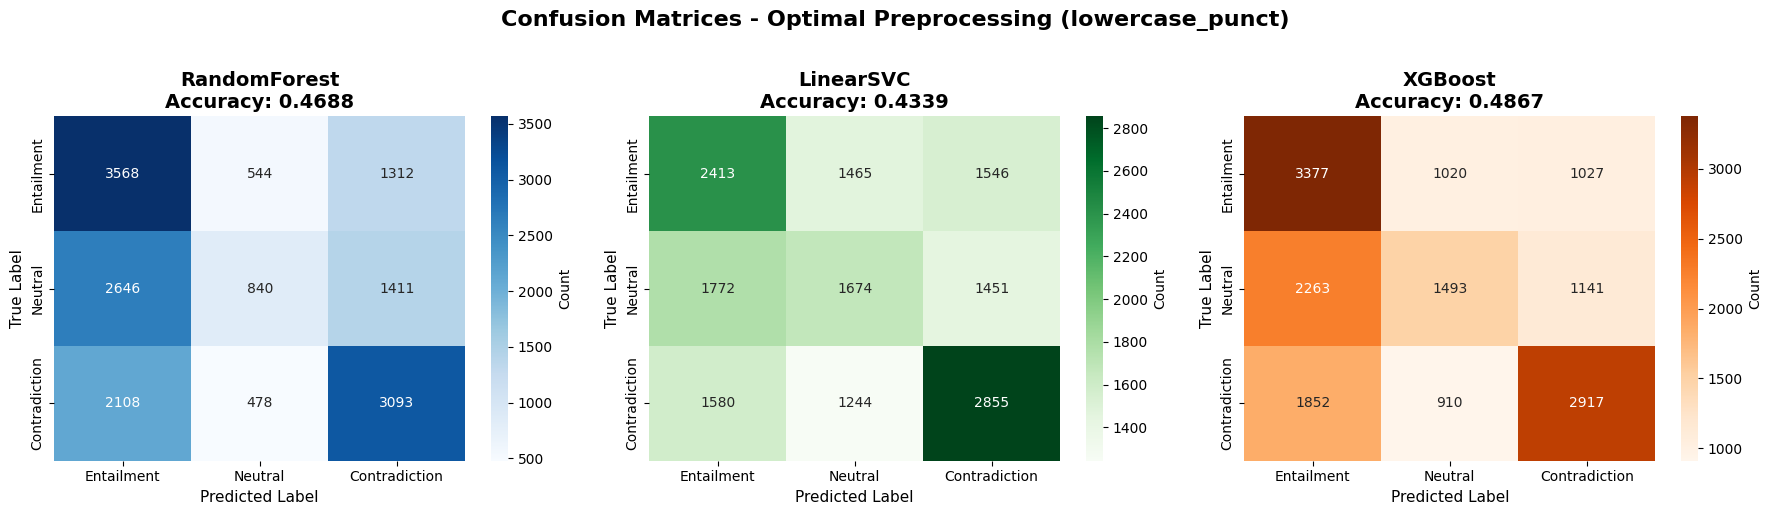


PER-CLASS ACCURACY COMPARISON

Entailment:
  RandomForest: 0.6578 (3568/5424)
  LinearSVC:    0.4449 (2413/5424)
  XGBoost:      0.6226 (3377/5424)

Neutral:
  RandomForest: 0.1715 (840/4897)
  LinearSVC:    0.3418 (1674/4897)
  XGBoost:      0.3049 (1493/4897)

Contradiction:
  RandomForest: 0.5446 (3093/5679)
  LinearSVC:    0.5027 (2855/5679)
  XGBoost:      0.5136 (2917/5679)



In [27]:
# Compute confusion matrices
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Class names
class_names = ['Entailment', 'Neutral', 'Contradiction']

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RandomForest Confusion Matrix
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, 
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title(f'RandomForest\nAccuracy: {rf_acc:.4f}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# LinearSVC Confusion Matrix
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title(f'LinearSVC\nAccuracy: {svm_acc:.4f}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

# XGBoost Confusion Matrix
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[2], cbar_kws={'label': 'Count'})
axes[2].set_title(f'XGBoost\nAccuracy: {xgb_acc:.4f}', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Predicted Label', fontsize=11)
axes[2].set_ylabel('True Label', fontsize=11)

plt.suptitle(f'Confusion Matrices - Optimal Preprocessing ({optimal_strategy})', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print per-class accuracies
print("\n" + "=" * 70)
print("PER-CLASS ACCURACY COMPARISON")
print("=" * 70)

for i, class_name in enumerate(class_names):
    rf_class_acc = cm_rf[i, i] / cm_rf[i].sum() if cm_rf[i].sum() > 0 else 0
    svm_class_acc = cm_svm[i, i] / cm_svm[i].sum() if cm_svm[i].sum() > 0 else 0
    xgb_class_acc = cm_xgb[i, i] / cm_xgb[i].sum() if cm_xgb[i].sum() > 0 else 0
    
    print(f"\n{class_name}:")
    print(f"  RandomForest: {rf_class_acc:.4f} ({cm_rf[i, i]}/{cm_rf[i].sum()})")
    print(f"  LinearSVC:    {svm_class_acc:.4f} ({cm_svm[i, i]}/{cm_svm[i].sum()})")
    print(f"  XGBoost:      {xgb_class_acc:.4f} ({cm_xgb[i, i]}/{cm_xgb[i].sum()})")

print("\n" + "=" * 70)

## 10. Normalized Confusion Matrices

Matrices de confusion normalisées pour mieux visualiser les proportions de prédictions.


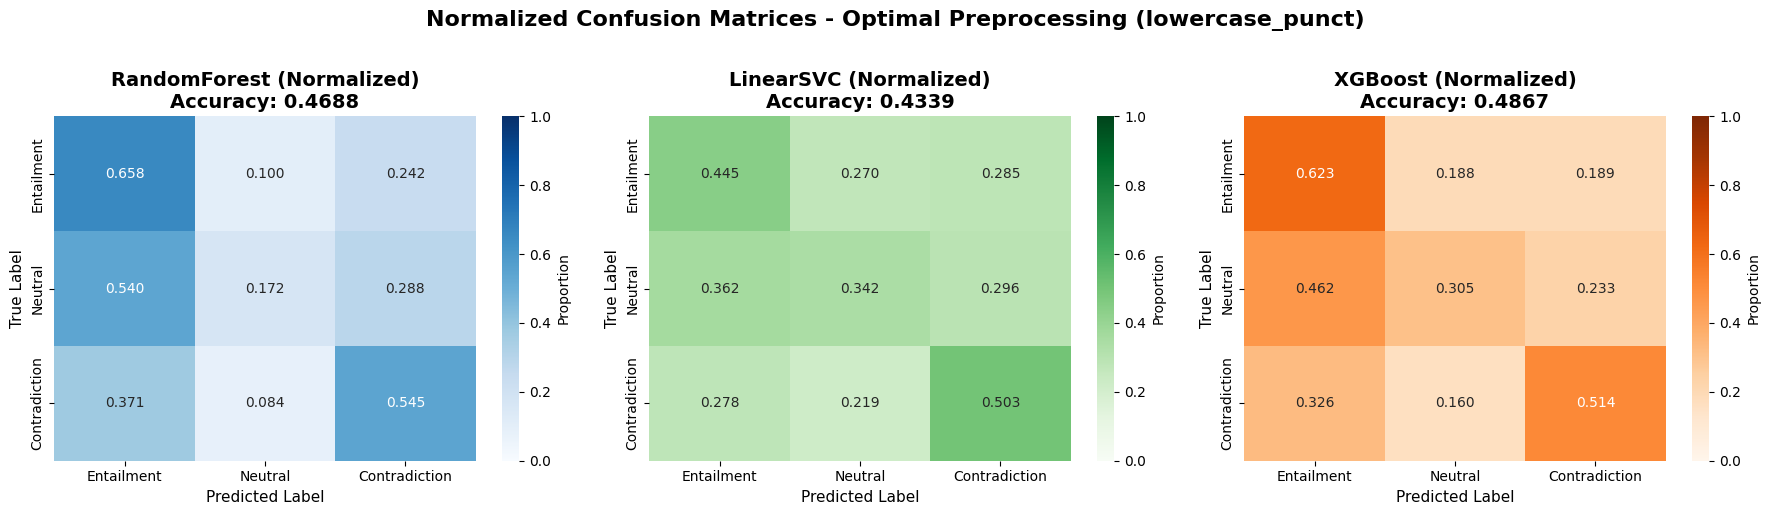


MISCLASSIFICATION ANALYSIS

Entailment (True Class):
  Misclassified as Neutral:
    RF: 10.0%, SVM: 27.0%, XGB: 18.8%
  Misclassified as Contradiction:
    RF: 24.2%, SVM: 28.5%, XGB: 18.9%

Neutral (True Class):
  Misclassified as Entailment:
    RF: 54.0%, SVM: 36.2%, XGB: 46.2%
  Misclassified as Contradiction:
    RF: 28.8%, SVM: 29.6%, XGB: 23.3%

Contradiction (True Class):
  Misclassified as Entailment:
    RF: 37.1%, SVM: 27.8%, XGB: 32.6%
  Misclassified as Neutral:
    RF: 8.4%, SVM: 21.9%, XGB: 16.0%

SUMMARY

Optimal Preprocessing: lowercase_punct

Overall Accuracy:
  RandomForest: 0.4688
  LinearSVC:    0.4339
  XGBoost:      0.4867

Best Model: XGBoost


In [28]:
# Compute normalized confusion matrices
cm_rf_norm = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis]
cm_svm_norm = cm_svm.astype('float') / cm_svm.sum(axis=1)[:, np.newaxis]
cm_xgb_norm = cm_xgb.astype('float') / cm_xgb.sum(axis=1)[:, np.newaxis]

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RandomForest Normalized Confusion Matrix
sns.heatmap(cm_rf_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], cbar_kws={'label': 'Proportion'}, vmin=0, vmax=1)
axes[0].set_title(f'RandomForest (Normalized)\nAccuracy: {rf_acc:.4f}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# LinearSVC Normalized Confusion Matrix
sns.heatmap(cm_svm_norm, annot=True, fmt='.3f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], cbar_kws={'label': 'Proportion'}, vmin=0, vmax=1)
axes[1].set_title(f'LinearSVC (Normalized)\nAccuracy: {svm_acc:.4f}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

# XGBoost Normalized Confusion Matrix
sns.heatmap(cm_xgb_norm, annot=True, fmt='.3f', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[2], cbar_kws={'label': 'Proportion'}, vmin=0, vmax=1)
axes[2].set_title(f'XGBoost (Normalized)\nAccuracy: {xgb_acc:.4f}', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Predicted Label', fontsize=11)
axes[2].set_ylabel('True Label', fontsize=11)

plt.suptitle(f'Normalized Confusion Matrices - Optimal Preprocessing ({optimal_strategy})',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Analysis of misclassifications
print("\n" + "=" * 70)
print("MISCLASSIFICATION ANALYSIS")
print("=" * 70)

for i, true_class in enumerate(class_names):
    print(f"\n{true_class} (True Class):")
    for j, pred_class in enumerate(class_names):
        if i != j:  # Only show misclassifications
            rf_misc = cm_rf_norm[i, j]
            svm_misc = cm_svm_norm[i, j]
            xgb_misc = cm_xgb_norm[i, j]
            
            print(f"  Misclassified as {pred_class}:")
            print(f"    RF: {rf_misc:.1%}, SVM: {svm_misc:.1%}, XGB: {xgb_misc:.1%}")

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"\nOptimal Preprocessing: {optimal_strategy}")
print(f"\nOverall Accuracy:")
print(f"  RandomForest: {rf_acc:.4f}")
print(f"  LinearSVC:    {svm_acc:.4f}")
print(f"  XGBoost:      {xgb_acc:.4f}")
print(f"\nBest Model: {'RandomForest' if rf_acc >= max(svm_acc, xgb_acc) else 'LinearSVC' if svm_acc >= xgb_acc else 'XGBoost'}")
print("=" * 70)